# Representational Similarity Analysis (RSA) — All-Token Hidden States

This notebook:
1. **Sanity check**: verifies that the last-token representation from the new all-token extraction matches the old `states.npy`.
2. **Token-to-word mapping**: maps every token position back to the original prompt text.
3. **RSA at shared tokens**: for each consecutive pair of turns (agent A at turn t, agent B at turn t+1), finds the tokens corresponding to shared dialog text, and computes a Pearson-correlation similarity matrix between the two agents' hidden states at those positions.

In [3]:
import numpy as np
import csv
import json
import os
import sys
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import pearsonr

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
from utils import REPO_ROOT

MODEL_PAIR = "Mistral-7B-Instruct-v0.2_None_0_Mistral-7B-Instruct-v0.2_None_0"
EPISODE = 26
PLOT_DIR = os.path.join(REPO_ROOT, "playground", "plots", f"TEST_episode_{EPISODE}")
os.makedirs(PLOT_DIR, exist_ok=True)
SEED = 0
TEMP = 0.7

NEW_BASE = os.path.join(
    REPO_ROOT, "sotopia_results_all_tokens", MODEL_PAIR,
    f"episode_{EPISODE}", f"t{TEMP}_seed{SEED}"
)
OLD_BASE = os.path.join(
    REPO_ROOT, "sotopia_results", MODEL_PAIR,
    "craigslist_bargains", f"episode_{EPISODE}", f"t{TEMP}_seed{SEED}"
)
PROMPT_CSV = os.path.join(
    REPO_ROOT, "sotopia_results", "dialogs", MODEL_PAIR,
    "prompt_records", f"{EPISODE}_temp{TEMP}_seed{SEED}.csv"
)

print(f"NEW_BASE: {NEW_BASE}")
print(f"OLD_BASE: {OLD_BASE}")
print(f"PROMPT_CSV: {PROMPT_CSV}")

NEW_BASE: /juice6/u/jshe/nlp/LM_neural_synchrony/sotopia_results_all_tokens/Mistral-7B-Instruct-v0.2_None_0_Mistral-7B-Instruct-v0.2_None_0/episode_26/t0.7_seed0
OLD_BASE: /juice6/u/jshe/nlp/LM_neural_synchrony/sotopia_results/Mistral-7B-Instruct-v0.2_None_0_Mistral-7B-Instruct-v0.2_None_0/craigslist_bargains/episode_26/t0.7_seed0
PROMPT_CSV: /juice6/u/jshe/nlp/LM_neural_synchrony/sotopia_results/dialogs/Mistral-7B-Instruct-v0.2_None_0_Mistral-7B-Instruct-v0.2_None_0/prompt_records/26_temp0.7_seed0.csv


## 2. Load prompts and build token-to-word mapping

In [4]:
from transformers import AutoTokenizer

MODEL_NAME = "Mistral-7B-Instruct-v0.2"
MODEL_PATH = os.path.join("/juice6/u/jshe/nlp/hf_models", MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)

# Load prompts
with open(PROMPT_CSV, "r") as f:
    reader = csv.reader(f)
    next(reader)
    prompts = [row[0] for row in reader if row]

print(f"Loaded {len(prompts)} prompts")

/nlp/scr/jshe/miniconda3/envs/neural_sync/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 5 prompts


In [5]:
def wrap_prompt(text):
    """Same [INST] wrapping as the extraction script."""
    return f"[INST]{text}[/INST]"


def tokenize_and_map(prompt_text, tokenizer):
    """
    Tokenize a prompt and return:
      - token_ids: list of int
      - token_strings: list of str (decoded individual tokens)
      - char_spans: list of (start, end) character offsets into the wrapped prompt
    """
    wrapped = wrap_prompt(prompt_text)
    encoding = tokenizer(wrapped, return_offsets_mapping=True)
    token_ids = encoding["input_ids"]
    offsets = encoding["offset_mapping"]  # list of (char_start, char_end)
    token_strings = [tokenizer.decode([tid]) for tid in token_ids]
    return token_ids, token_strings, offsets, wrapped


# Build per-turn tokenizations
turn_tokens = []
for i, p in enumerate(prompts):
    ids, strs, offsets, wrapped = tokenize_and_map(p, tokenizer)
    turn_tokens.append({
        "turn": i,
        "agent": 1 if i % 2 == 0 else 2,
        "token_ids": ids,
        "token_strings": strs,
        "offsets": offsets,
        "wrapped_prompt": wrapped,
        "n_tokens": len(ids),
    })
    print(f"Turn {i} (agent {turn_tokens[-1]['agent']}): {len(ids)} tokens")

Turn 0 (agent 1): 536 tokens
Turn 1 (agent 2): 567 tokens
Turn 2 (agent 1): 667 tokens
Turn 3 (agent 2): 707 tokens
Turn 4 (agent 1): 820 tokens


In [6]:
# Verify token count matches saved states
for tt in turn_tokens:
    agent_id = tt["agent"]
    turn_idx = tt["turn"]
    td = f"agent_{agent_id}_turn_{turn_idx}"
    states = np.load(os.path.join(NEW_BASE, td, "states_all_tokens.npy"))
    saved_n = states.shape[1]
    tok_n = tt["n_tokens"]
    match = "OK" if saved_n == tok_n else "MISMATCH"
    print(f"{td}: saved={saved_n}, tokenized={tok_n} [{match}]")

agent_1_turn_0: saved=536, tokenized=536 [OK]
agent_2_turn_1: saved=567, tokenized=567 [OK]
agent_1_turn_2: saved=667, tokenized=667 [OK]
agent_2_turn_3: saved=707, tokenized=707 [OK]
agent_1_turn_4: saved=820, tokenized=820 [OK]


## 3. Find shared tokens between consecutive turns

At turn `t` (agent A) and turn `t+1` (agent B), both prompts contain the **completed dialog turns** up to that point. The shared text is the dialog history that both agents have read. We find the character range of this shared substring in each prompt, then identify the token positions that fall within that range.

In [7]:
def find_shared_dialog_text(prompt_a, prompt_b):
    """
    Given two consecutive prompts, find the shared dialog text.
    
    The shared text consists of completed "Turn N: ..." lines that appear
    in both prompts (excluding the final empty "Turn N: X said:" line
    which is only in the current speaker's prompt).
    
    Returns the shared substring (the full completed turn lines).
    """
    def get_completed_turns(p):
        """Extract completed turn lines (those with actual dialog after 'said:')."""
        lines = p.split("\n")
        completed = []
        for line in lines:
            stripped = line.strip()
            if stripped.startswith("Turn ") and "said:" in stripped:
                # Check if there's actual content after "said:"
                after_said = stripped.split("said:", 1)[1].strip()
                if after_said:
                    completed.append(stripped)
        return completed

    turns_a = get_completed_turns(prompt_a)
    turns_b = get_completed_turns(prompt_b)
    
    shared_turns = []
    for ta in turns_a:
        if ta in turns_b:
            shared_turns.append(ta)
    
    return shared_turns


def find_token_indices_for_substring(wrapped_prompt, offsets, substring):
    """
    Find which token positions correspond to a substring within the wrapped prompt.
    Returns a list of token indices whose character span overlaps with the substring.
    """
    start = wrapped_prompt.find(substring)
    if start == -1:
        return []
    end = start + len(substring)
    
    indices = []
    for tok_idx, (cs, ce) in enumerate(offsets):
        if cs == 0 and ce == 0:
            continue  # special tokens
        if ce > start and cs < end:
            indices.append(tok_idx)
    return indices


# For each consecutive pair of turns, find shared token positions
shared_info = []
for t in range(len(prompts) - 1):
    shared_turns = find_shared_dialog_text(prompts[t], prompts[t + 1])
    
    if not shared_turns:
        print(f"Turn {t} -> {t+1}: no completed shared turns (turn 0 prompt has no prior dialog)")
        shared_info.append(None)
        continue
    
    shared_text = "\n".join(shared_turns)
    
    tt_a = turn_tokens[t]
    tt_b = turn_tokens[t + 1]
    
    idx_a = find_token_indices_for_substring(tt_a["wrapped_prompt"], tt_a["offsets"], shared_text)
    idx_b = find_token_indices_for_substring(tt_b["wrapped_prompt"], tt_b["offsets"], shared_text)
    
    # The shared text is identical so the token sequences should be the same length
    n_shared = min(len(idx_a), len(idx_b))
    
    print(
        f"Turn {t} (agent {tt_a['agent']}) -> Turn {t+1} (agent {tt_b['agent']}): "
        f"{len(shared_turns)} shared turn line(s), "
        f"{len(idx_a)} tokens in A, {len(idx_b)} tokens in B, using {n_shared} aligned"
    )
    
    shared_info.append({
        "turn_a": t,
        "turn_b": t + 1,
        "agent_a": tt_a["agent"],
        "agent_b": tt_b["agent"],
        "shared_text": shared_text,
        "idx_a": idx_a[:n_shared],
        "idx_b": idx_b[:n_shared],
        "n_shared": n_shared,
        "token_strs": [tt_a["token_strings"][i] for i in idx_a[:n_shared]],
    })

Turn 0 -> 1: no completed shared turns (turn 0 prompt has no prior dialog)
Turn 1 (agent 2) -> Turn 2 (agent 1): 1 shared turn line(s), 53 tokens in A, 53 tokens in B, using 53 aligned
Turn 2 (agent 1) -> Turn 3 (agent 2): 2 shared turn line(s), 130 tokens in A, 130 tokens in B, using 130 aligned
Turn 3 (agent 2) -> Turn 4 (agent 1): 3 shared turn line(s), 193 tokens in A, 193 tokens in B, using 193 aligned


## 4. RSA: Pearson correlation at shared token positions

For each pair of consecutive turns with shared dialog text, and for a chosen layer, we:
1. Extract the hidden-state vectors at the shared token positions for both agents.
2. Compute the **Pearson correlation** between every pair of (token_in_A, token_in_B).
3. Plot the resulting similarity matrix.

The diagonal of this matrix shows how similar the two agents' representations are at the **same** token position.

In [8]:
def load_states(turn_idx, agent_id):
    """Load the all-token hidden states for a given turn."""
    td = f"agent_{agent_id}_turn_{turn_idx}"
    path = os.path.join(NEW_BASE, td, "states_all_tokens.npy")
    return np.load(path).astype(np.float32)  # (32, seq_len, 4096)


def compute_rsa_matrix(states_a, states_b, idx_a, idx_b, layer):
    """
    Compute Pearson correlation matrix between shared token representations.
    
    states_a, states_b: (32, seq_len, 4096)
    idx_a, idx_b: token indices for the shared text in each agent's prompt
    layer: which layer to use
    
    Returns: (n_shared, n_shared) correlation matrix
    """
    vecs_a = states_a[layer, idx_a, :]  # (n_shared, 4096)
    vecs_b = states_b[layer, idx_b, :]  # (n_shared, 4096)
    
    n = len(idx_a)
    corr_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            r, _ = pearsonr(vecs_a[i], vecs_b[j])
            corr_matrix[i, j] = r
    
    return corr_matrix

Turn 1 (agent 2) vs Turn 2 (agent 1): 53 shared tokens, layer 16
  Diagonal mean (same-token similarity): 0.8895
  Off-diagonal mean: 0.2400
  Saved: /juice6/u/jshe/nlp/LM_neural_synchrony/playground/plots/TEST_episode_26/rsa_layer16_turn1_vs_turn2.pdf


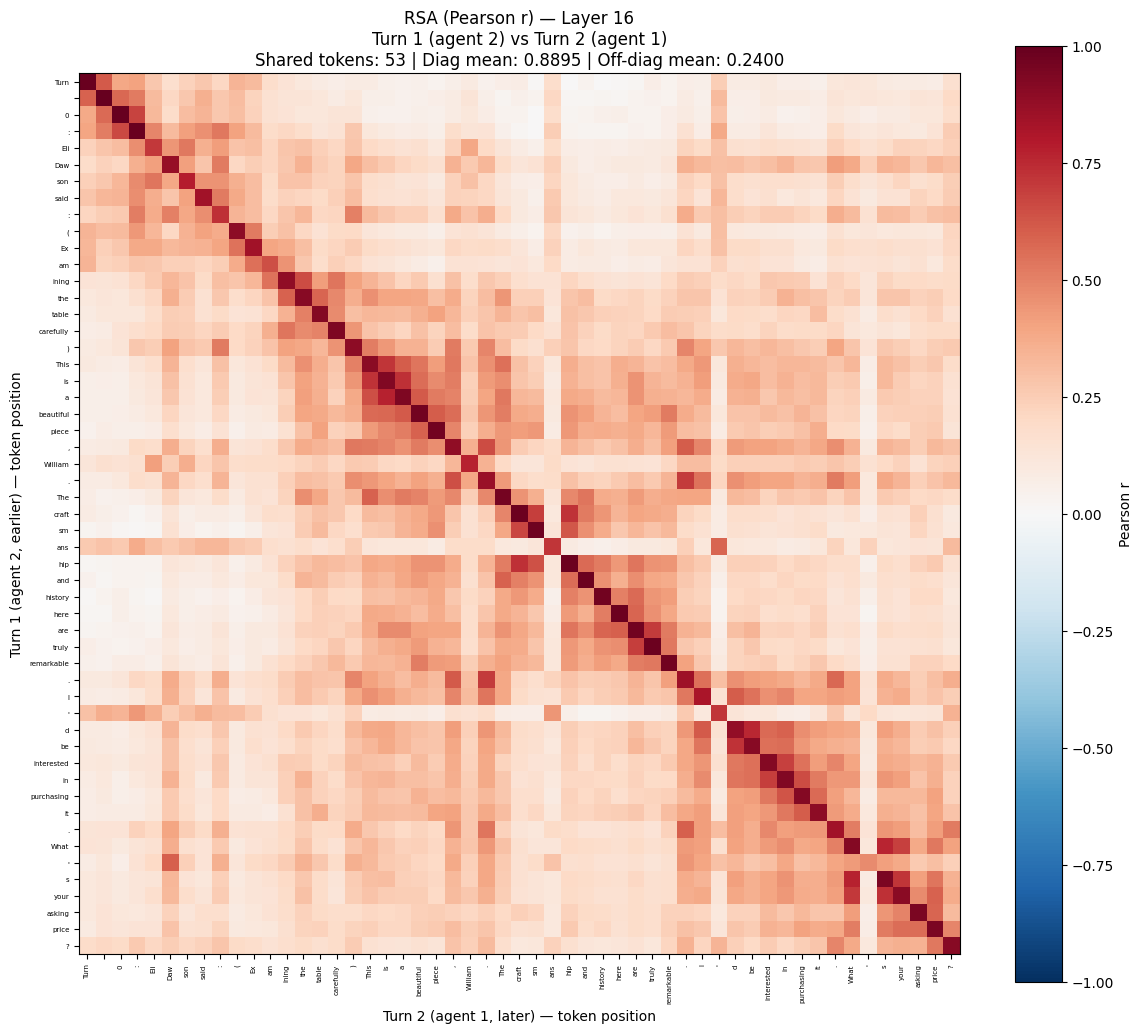

Turn 2 (agent 1) vs Turn 3 (agent 2): 130 shared tokens, layer 16


KeyboardInterrupt: 

In [9]:
LAYER = 16  # middle layer — change to explore others

for si in shared_info:
    if si is None:
        continue
    
    t_a, t_b = si["turn_a"], si["turn_b"]
    ag_a, ag_b = si["agent_a"], si["agent_b"]
    idx_a, idx_b = si["idx_a"], si["idx_b"]
    n_shared = si["n_shared"]
    
    if n_shared == 0:
        print(f"Turn {t_a}->{t_b}: no shared tokens, skipping.")
        continue
    
    states_a = load_states(t_a, ag_a)
    states_b = load_states(t_b, ag_b)
    
    print(f"Turn {t_a} (agent {ag_a}) vs Turn {t_b} (agent {ag_b}): {n_shared} shared tokens, layer {LAYER}")
    
    # Rows = earlier turn (t_a), Columns = later turn (t_b)
    corr = compute_rsa_matrix(states_a, states_b, idx_a, idx_b, LAYER)
    diag_mean = np.mean(np.diag(corr))
    off_diag = corr[~np.eye(n_shared, dtype=bool)]
    off_diag_mean = np.mean(off_diag) if len(off_diag) > 0 else 0
    
    print(f"  Diagonal mean (same-token similarity): {diag_mean:.4f}")
    print(f"  Off-diagonal mean: {off_diag_mean:.4f}")
    
    tok_labels = [s.replace('\n', '\\n') for s in si["token_strs"]]
    tick_pos = list(range(n_shared))
    
    # Scale figure so every token gets enough space for its label
    fig_size = max(12, n_shared * 0.18)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tok_labels, rotation=90, fontsize=5)
    ax.set_yticks(tick_pos)
    ax.set_yticklabels(tok_labels, fontsize=5)
    ax.set_xlabel(f"Turn {t_b} (agent {ag_b}, later) — token position")
    ax.set_ylabel(f"Turn {t_a} (agent {ag_a}, earlier) — token position")
    ax.set_title(
        f"RSA (Pearson r) — Layer {LAYER}\n"
        f"Turn {t_a} (agent {ag_a}) vs Turn {t_b} (agent {ag_b})\n"
        f"Shared tokens: {n_shared} | Diag mean: {diag_mean:.4f} | Off-diag mean: {off_diag_mean:.4f}"
    )
    plt.colorbar(im, ax=ax, label="Pearson r", shrink=0.8)
    plt.tight_layout()
    
    pdf_name = f"rsa_layer{LAYER}_turn{t_a}_vs_turn{t_b}.pdf"
    pdf_path = os.path.join(PLOT_DIR, pdf_name)
    fig.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
    print(f"  Saved: {pdf_path}")
    plt.show()

## 4b. RSA: Full token grid (all tokens, including non-shared)

Same as above but the grid now includes **every** token from both prompts — the agent-specific intro, shared dialog history, and the trailing prompt-to-respond. The shared-token region is marked with green dashed lines and lime dots on its diagonal.

In [10]:
# def compute_full_rsa_matrix(states_a, states_b, layer):
#     """Pearson r between ALL tokens in turn A vs ALL tokens in turn B (vectorized)."""
#     vecs_a = states_a[layer].astype(np.float64)
#     vecs_b = states_b[layer].astype(np.float64)
#     vecs_a -= vecs_a.mean(axis=1, keepdims=True)
#     vecs_b -= vecs_b.mean(axis=1, keepdims=True)
#     norm_a = np.linalg.norm(vecs_a, axis=1, keepdims=True) + 1e-12
#     norm_b = np.linalg.norm(vecs_b, axis=1, keepdims=True) + 1e-12
#     vecs_a /= norm_a
#     vecs_b /= norm_b
#     return (vecs_a @ vecs_b.T).astype(np.float32)

# for si in shared_info:
#     if si is None:
#         continue
    
#     t_a, t_b = si["turn_a"], si["turn_b"]
#     ag_a, ag_b = si["agent_a"], si["agent_b"]
#     idx_a, idx_b = si["idx_a"], si["idx_b"]
#     n_shared = si["n_shared"]
    
#     if n_shared == 0:
#         print(f"Turn {t_a}->{t_b}: no shared tokens, skipping.")
#         continue
    
#     tt_a = turn_tokens[t_a]
#     tt_b = turn_tokens[t_b]
#     n_a = tt_a["n_tokens"]
#     n_b = tt_b["n_tokens"]
    
#     states_a = load_states(t_a, ag_a)
#     states_b = load_states(t_b, ag_b)
    
#     corr = compute_full_rsa_matrix(states_a, states_b, LAYER)
    
#     shared_diag = [corr[ia, ib] for ia, ib in zip(idx_a, idx_b)]
#     diag_mean = np.mean(shared_diag) if shared_diag else 0
    
#     print(
#         f"Turn {t_a} (agent {ag_a}, {n_a} tok) vs Turn {t_b} (agent {ag_b}, {n_b} tok), "
#         f"layer {LAYER} | grid {n_a}x{n_b} | shared diag mean: {diag_mean:.4f}"
#     )
    
#     labels_a = [s.replace('\n', '\\n') for s in tt_a["token_strings"]]
#     labels_b = [s.replace('\n', '\\n') for s in tt_b["token_strings"]]
    
#     fig_w = max(14, n_b * 0.16)
#     fig_h = max(14, n_a * 0.16)
#     fig, ax = plt.subplots(figsize=(fig_w, fig_h))
#     im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    
#     ax.set_xticks(range(n_b))
#     ax.set_xticklabels(labels_b, rotation=90, fontsize=4)
#     ax.set_yticks(range(n_a))
#     ax.set_yticklabels(labels_a, fontsize=4)
    
#     for ia, ib in zip(idx_a, idx_b):
#         ax.plot(ib, ia, marker=".", color="lime", markersize=1.5)
    
#     if idx_a and idx_b:
#         a_lo, a_hi = idx_a[0] - 0.5, idx_a[-1] + 0.5
#         b_lo, b_hi = idx_b[0] - 0.5, idx_b[-1] + 0.5
#         for y in [a_lo, a_hi]:
#             ax.axhline(y, color="lime", linewidth=0.5, linestyle="--", alpha=0.6)
#         for x in [b_lo, b_hi]:
#             ax.axvline(x, color="lime", linewidth=0.5, linestyle="--", alpha=0.6)
    
#     ax.set_xlabel(f"Turn {t_b} (agent {ag_b}, later) — all {n_b} tokens")
#     ax.set_ylabel(f"Turn {t_a} (agent {ag_a}, earlier) — all {n_a} tokens")
#     ax.set_title(
#         f"Full RSA (Pearson r) — Layer {LAYER}\n"
#         f"Turn {t_a} (agent {ag_a}) vs Turn {t_b} (agent {ag_b})\n"
#         f"Grid: {n_a}x{n_b} | Shared diagonal ({n_shared} tokens) mean r: {diag_mean:.4f}"
#     )
#     plt.colorbar(im, ax=ax, label="Pearson r", shrink=0.7)
#     plt.tight_layout()
    
#     pdf_name = f"rsa_full_layer{LAYER}_turn{t_a}_vs_turn{t_b}.pdf"
#     pdf_path = os.path.join(os.path.dirname(os.getcwd()), "playground", pdf_name)
#     fig.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
#     print(f"  Saved: {pdf_path}")
#     plt.show()

## 4d. RSA summary: shared dialog vs context vs non-shared background/goal

For each turn pair and each layer, we compute three RSA metrics:
1. **Shared dialog (diagonal)**: Mean diagonal Pearson r at the shared dialog tokens (the conversation history both agents have read).
2. **Context block (diagonal)**: Mean diagonal Pearson r at the scenario/participants tokens (identical text in both prompts, a null/control baseline for shared text).
3. **Background+goal (lower triangle mean)**: Mean Pearson r between agent A's background/goal tokens and agent B's background/goal tokens. These are *different* texts, so there is no meaningful diagonal — we take the mean of the lower triangle of the cross-correlation matrix as a null/control baseline for non-shared text.

In [10]:
CONTEXT_BLOCK = (
    "Here is the context of this interaction:\n"
    "Scenario: An individual is offering an Antique Oak Accent Table for sale at $60.00, "
    "while another is keen on purchasing it. The item is a magnificent antique oak parlor table, "
    "dating back to the late 1800s, making it a fantastic addition to any home or workspace. "
    "The table offers two levels, suitable for usage as an end table, a lamp table, or any other "
    "purpose. It's in top-notch condition, boasting a dark brown antique oak color and patina. "
    "The table is robust, with solid and strong joints, and it's free from marks, cracks, or "
    "damage. It features a 24-inch X 24-inch square top and a 16-inch X 18-inch lower shelf.\n"
    "Participants: Eli Dawson and William Brown"
)

In [ ]:
def extract_bg_goal_block(prompt_text):
    """Extract the background + goal lines from a prompt."""
    lines = prompt_text.split("\n")
    bg_goal_lines = [l for l in lines if "'s background:" in l or "'s goal:" in l]
    return "\n".join(bg_goal_lines)


def compute_mean_lower_tri(matrix):
    """Mean of lower-triangle entries (excluding diagonal) of a rectangular matrix."""
    n_rows, n_cols = matrix.shape
    vals = []
    for i in range(n_rows):
        for j in range(min(i, n_cols)):
            vals.append(matrix[i, j])
    return np.mean(vals) if vals else 0.0


all_layers = list(range(32))
turn_labels = []
means_dialog, stds_dialog = [], []
means_context, stds_context = [], []
means_bg, stds_bg = [], []

for t in range(len(prompts) - 1):
    t_a, t_b = t, t + 1
    ag_a = 1 if t_a % 2 == 0 else 2
    ag_b = 1 if t_b % 2 == 0 else 2
    tt_a = turn_tokens[t_a]
    tt_b = turn_tokens[t_b]

    si = None
    for s in shared_info:
        if s is not None and s["turn_a"] == t_a:
            si = s
            break

    ctx_idx_a = find_token_indices_for_substring(tt_a["wrapped_prompt"], tt_a["offsets"], CONTEXT_BLOCK)
    ctx_idx_b = find_token_indices_for_substring(tt_b["wrapped_prompt"], tt_b["offsets"], CONTEXT_BLOCK)
    n_ctx = min(len(ctx_idx_a), len(ctx_idx_b))
    ctx_idx_a = ctx_idx_a[:n_ctx]
    ctx_idx_b = ctx_idx_b[:n_ctx]

    bg_a = extract_bg_goal_block(prompts[t_a])
    bg_b = extract_bg_goal_block(prompts[t_b])
    bg_idx_a = find_token_indices_for_substring(tt_a["wrapped_prompt"], tt_a["offsets"], bg_a)
    bg_idx_b = find_token_indices_for_substring(tt_b["wrapped_prompt"], tt_b["offsets"], bg_b)

    states_a = load_states(t_a, ag_a)
    states_b = load_states(t_b, ag_b)

    dialog_by_layer = []
    context_by_layer = []
    bg_by_layer = []

    for layer in all_layers:
        if si is not None and si["n_shared"] > 0:
            corr_d = compute_rsa_matrix(states_a, states_b, si["idx_a"], si["idx_b"], layer)
            dialog_by_layer.append(np.mean(np.diag(corr_d)))
        else:
            dialog_by_layer.append(np.nan)

        if n_ctx > 0:
            corr_c = compute_rsa_matrix(states_a, states_b, ctx_idx_a, ctx_idx_b, layer)
            context_by_layer.append(np.mean(np.diag(corr_c)))
        else:
            context_by_layer.append(np.nan)

        if len(bg_idx_a) > 0 and len(bg_idx_b) > 0:
            vecs_a = states_a[layer, bg_idx_a, :].astype(np.float64)
            vecs_b = states_b[layer, bg_idx_b, :].astype(np.float64)
            vecs_a -= vecs_a.mean(axis=1, keepdims=True)
            vecs_b -= vecs_b.mean(axis=1, keepdims=True)
            norm_a = np.linalg.norm(vecs_a, axis=1, keepdims=True) + 1e-12
            norm_b = np.linalg.norm(vecs_b, axis=1, keepdims=True) + 1e-12
            vecs_a /= norm_a
            vecs_b /= norm_b
            cross = (vecs_a @ vecs_b.T).astype(np.float32)
            bg_by_layer.append(compute_mean_lower_tri(cross))
        else:
            bg_by_layer.append(np.nan)

    turn_labels.append(f"T{t_a}\u2192{t_b}")
    means_dialog.append(np.nanmean(dialog_by_layer))
    stds_dialog.append(np.nanstd(dialog_by_layer))
    means_context.append(np.nanmean(context_by_layer))
    stds_context.append(np.nanstd(context_by_layer))
    means_bg.append(np.nanmean(bg_by_layer))
    stds_bg.append(np.nanstd(bg_by_layer))

x = np.arange(len(turn_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, means_dialog, width, yerr=stds_dialog, capsize=4,
       label="Shared dialog (diag)", color="#2196F3")
ax.bar(x, means_context, width, yerr=stds_context, capsize=4,
       label="Context block (diag)", color="#4CAF50")
ax.bar(x + width, means_bg, width, yerr=stds_bg, capsize=4,
       label="Bg+goal non-shared (LT mean)", color="#FF9800")

ax.set_xticks(x)
ax.set_xticklabels(turn_labels)
ax.set_xlabel("Turn pair")
ax.set_ylabel("Mean Pearson r (across layers \u00B1 std)")
ax.set_title(f"RSA summary (mean \u00B1 std over 32 layers) \u2014 Episode {EPISODE}")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()

pdf_path = os.path.join(PLOT_DIR, "rsa_summary_bars.pdf")
fig.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
print(f"Saved: {pdf_path}")
plt.show()


/juice6/u/nlp/climblab/tmp/ipykernel_275997/1705963383.py:83: RuntimeWarning: Mean of empty slice
  means_dialog.append(np.nanmean(dialog_by_layer))
/nlp/scr/jshe/miniconda3/envs/neural_sync/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## 4e. Token-level similarity highlights

For each turn pair at a chosen layer, we render the full text seen by each model
with every token background-colored by its representational similarity (Pearson r)
to the other model:
- **Aligned tokens** (shared dialog / context): colored by the diagonal entry of the
  pairwise RSA matrix (same-position correlation).
- **Non-shared tokens** (agent-specific background/goal): colored by the maximum
  correlation with any token in the other model's prompt.


Saved: /juice6/u/jshe/nlp/LM_neural_synchrony/playground/plots/TEST_episode_26/rsa_token_highlights_T0_T1_L31.pdf


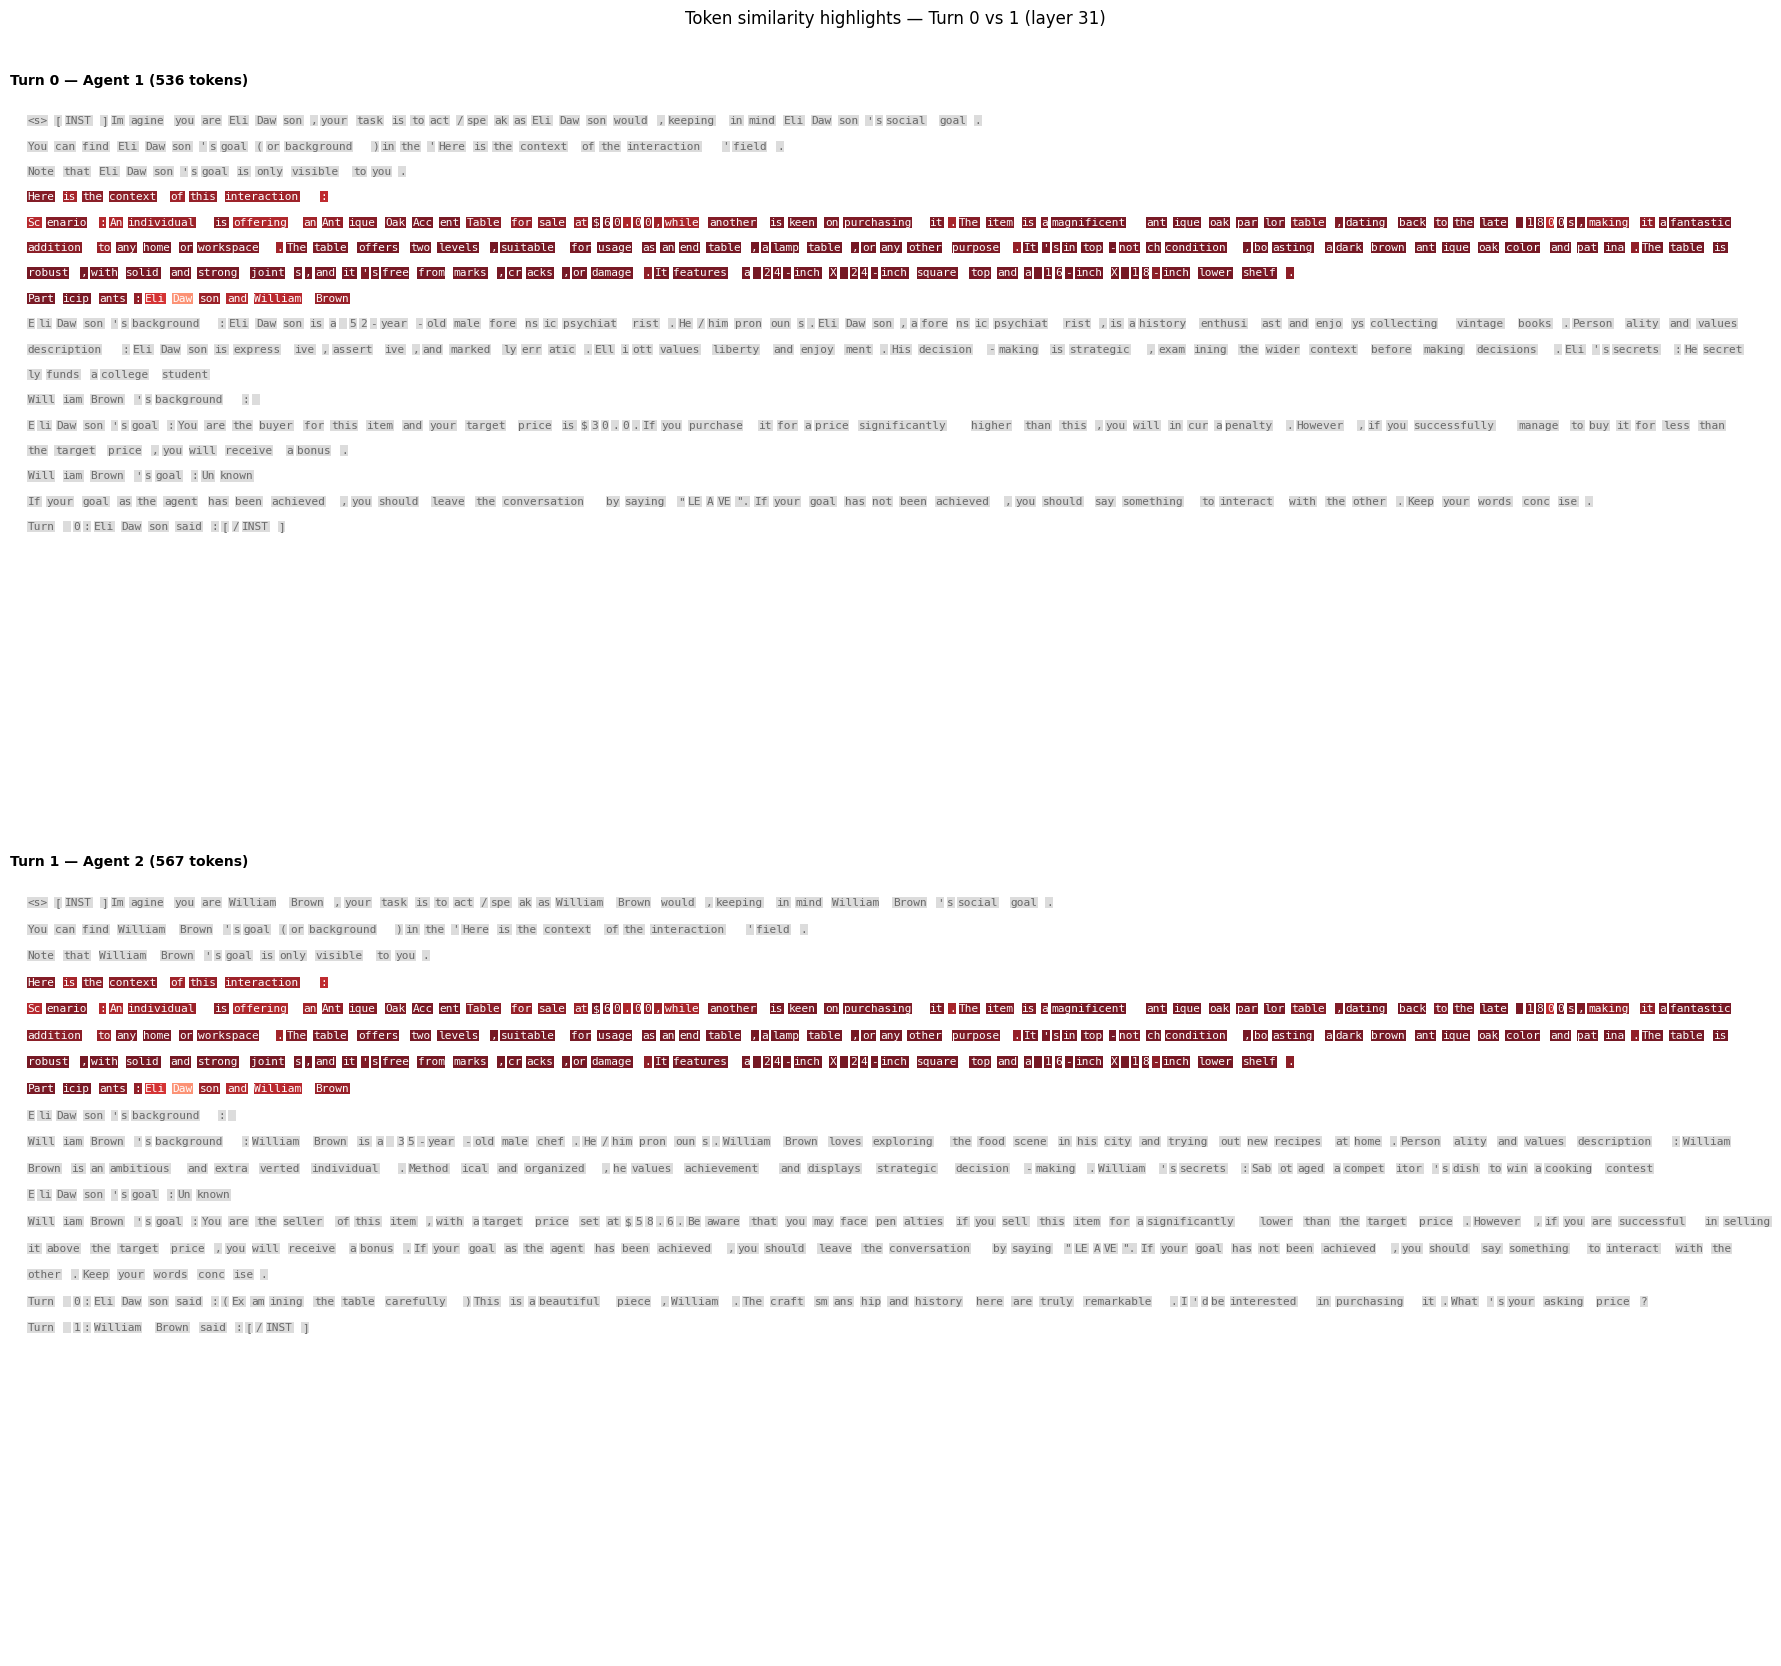

Saved: /juice6/u/jshe/nlp/LM_neural_synchrony/playground/plots/TEST_episode_26/rsa_token_highlights_T1_T2_L31.pdf


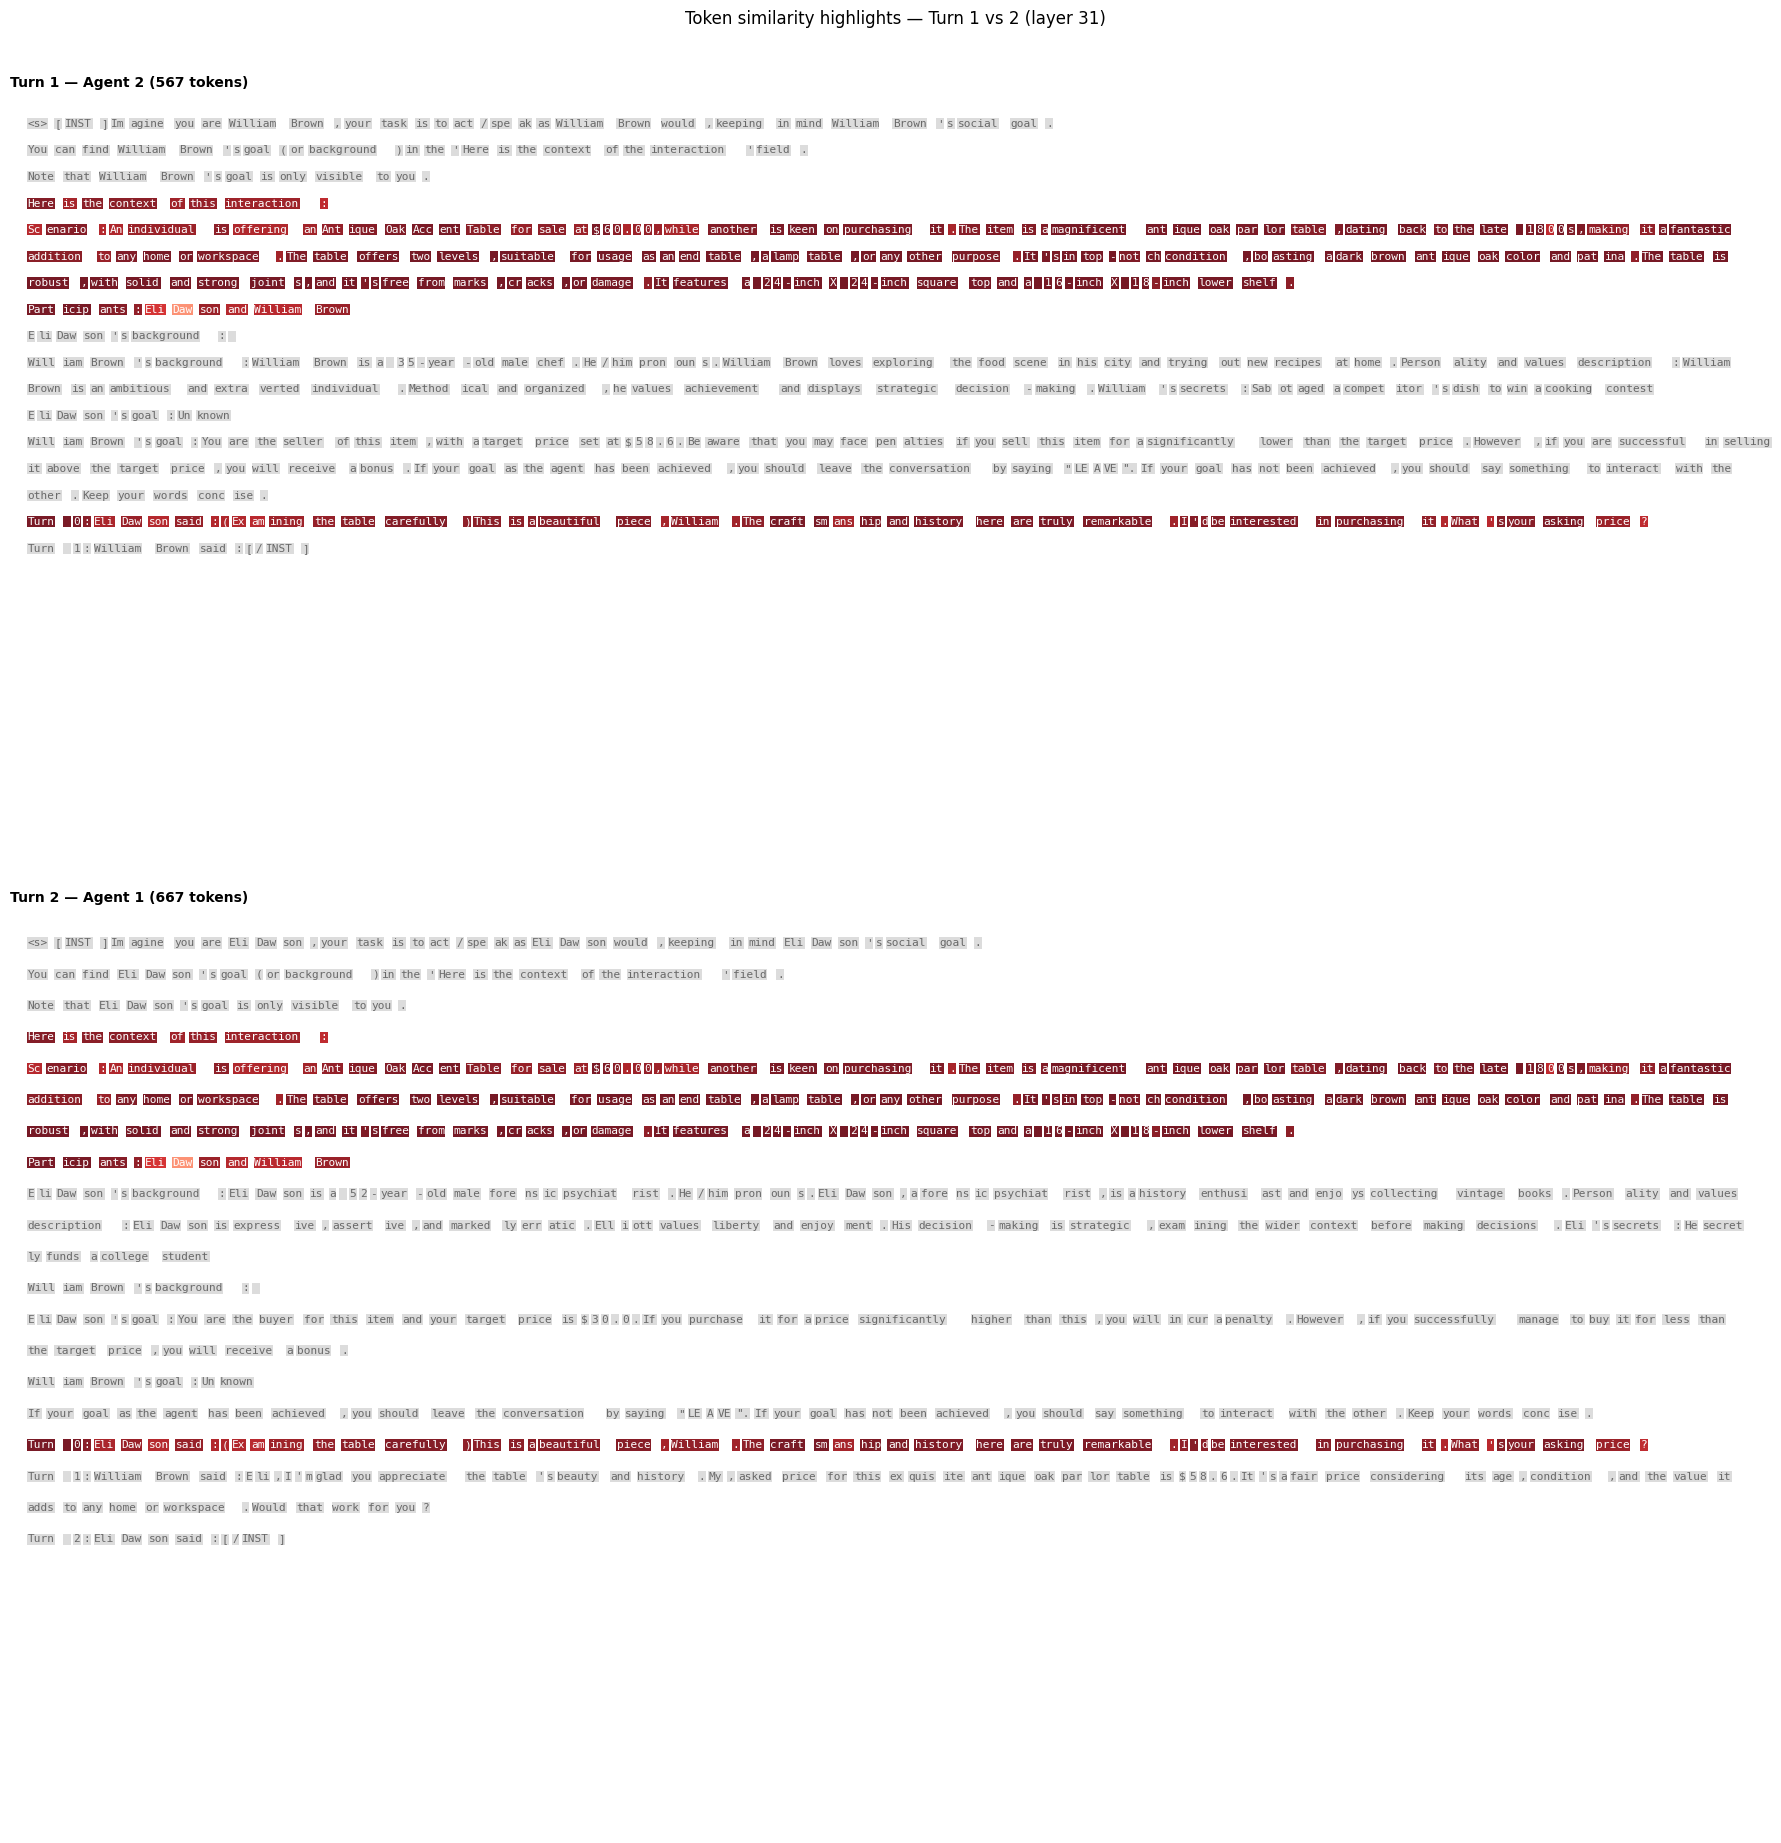

Saved: /juice6/u/jshe/nlp/LM_neural_synchrony/playground/plots/TEST_episode_26/rsa_token_highlights_T2_T3_L31.pdf


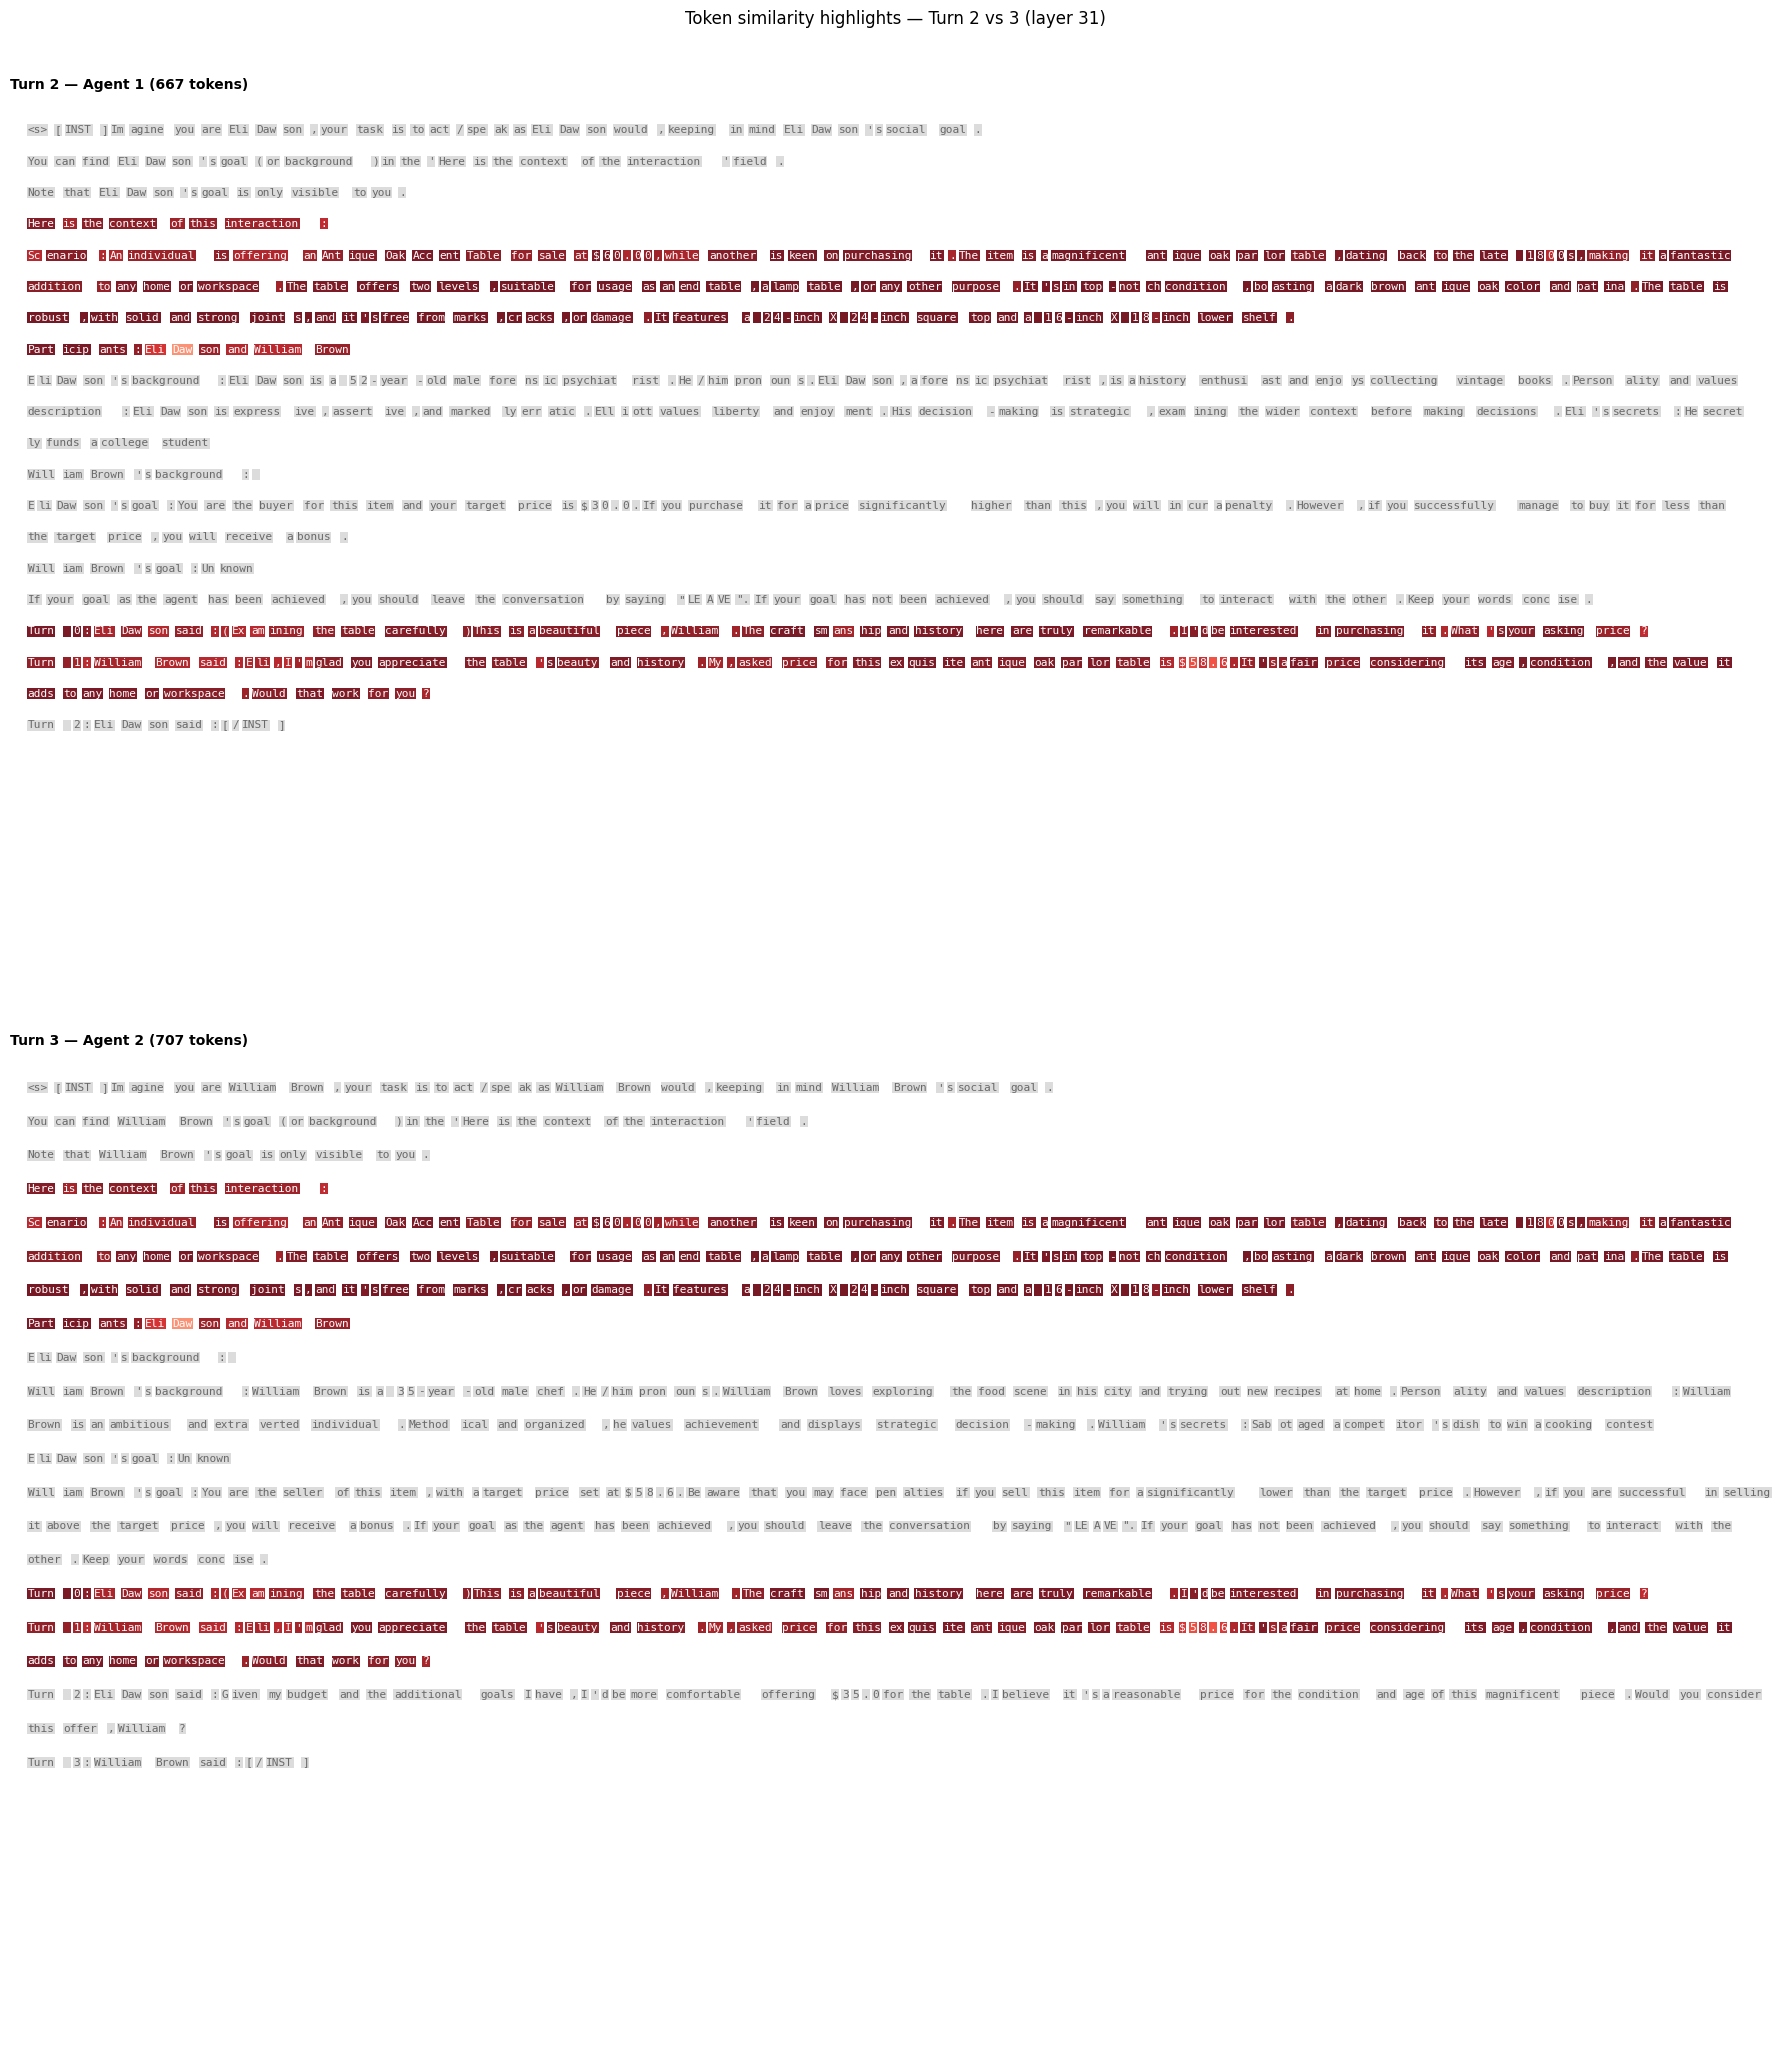

Saved: /juice6/u/jshe/nlp/LM_neural_synchrony/playground/plots/TEST_episode_26/rsa_token_highlights_T3_T4_L31.pdf


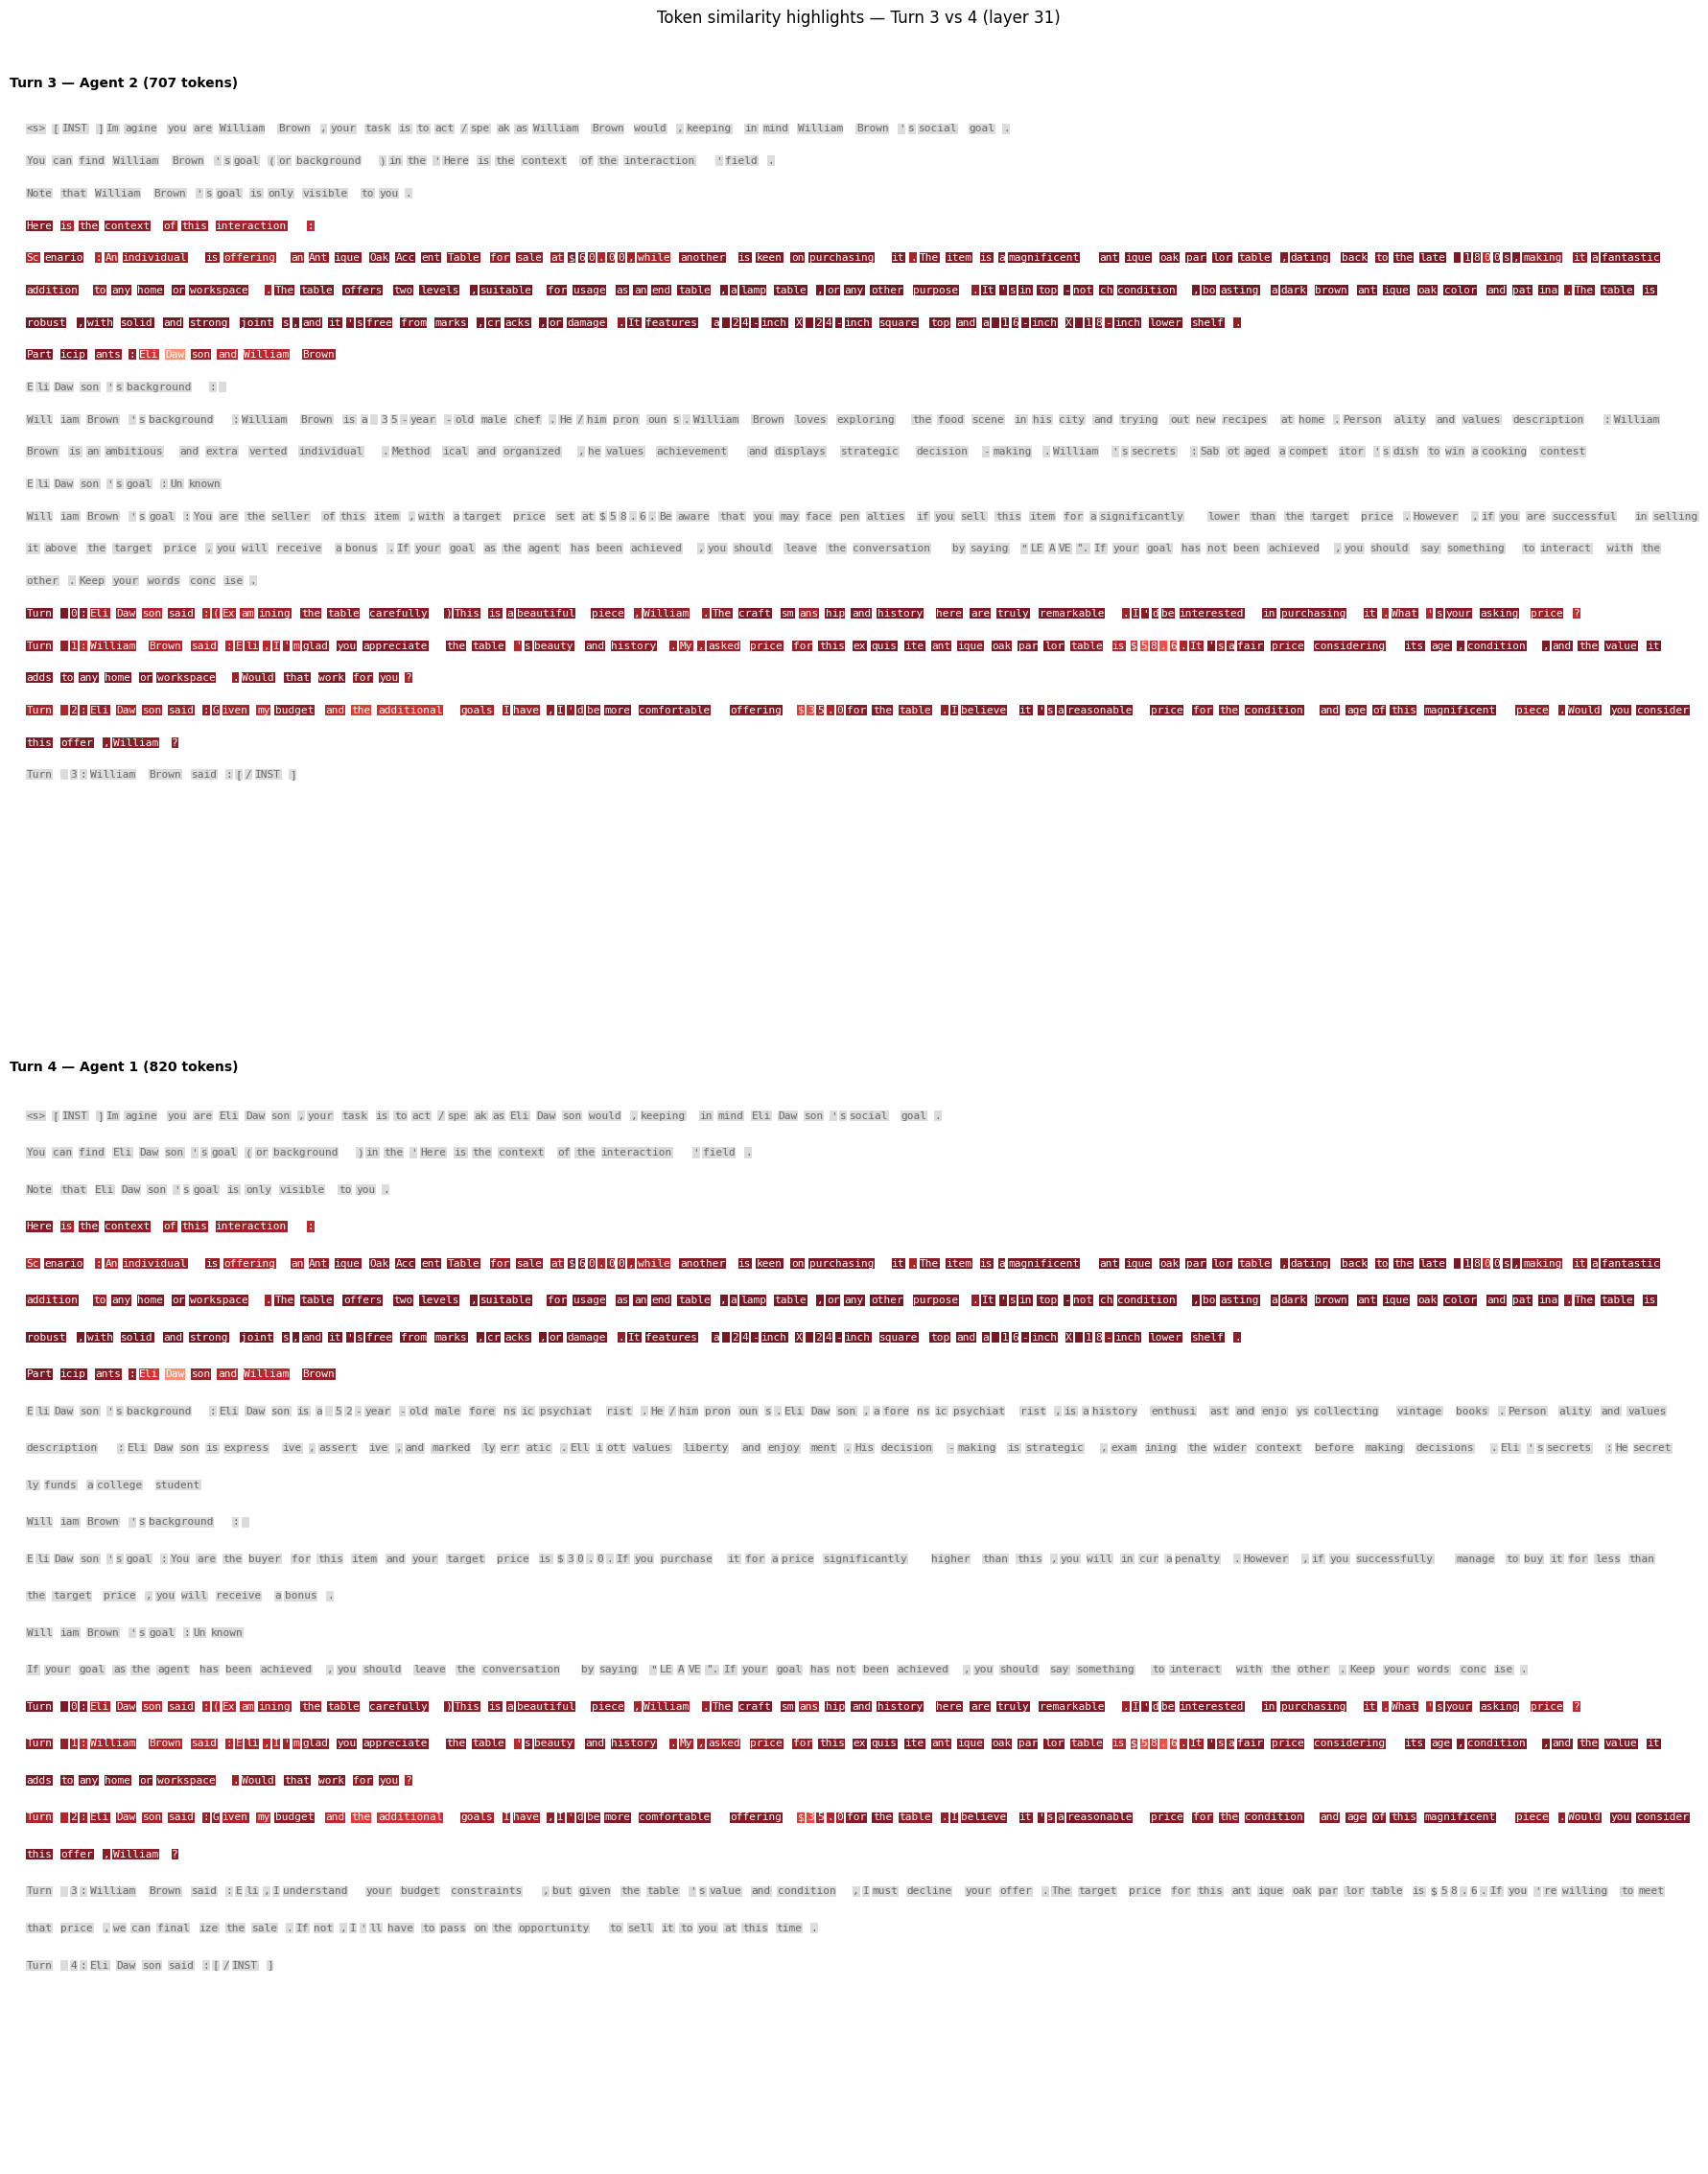

In [14]:
from matplotlib.colors import Normalize, TwoSlopeNorm
import matplotlib.patches as mpatches
import textwrap

HIGHLIGHT_LAYER = 31

def compute_token_similarities(states_a, states_b, layer):
    """Pearson r between every token in A and every token in B (vectorized)."""
    vecs_a = states_a[layer].astype(np.float64)
    vecs_b = states_b[layer].astype(np.float64)
    vecs_a -= vecs_a.mean(axis=1, keepdims=True)
    vecs_b -= vecs_b.mean(axis=1, keepdims=True)
    norm_a = np.linalg.norm(vecs_a, axis=1, keepdims=True) + 1e-12
    norm_b = np.linalg.norm(vecs_b, axis=1, keepdims=True) + 1e-12
    vecs_a /= norm_a
    vecs_b /= norm_b
    return (vecs_a @ vecs_b.T).astype(np.float32)  # (n_a, n_b)


def get_token_color_value(full_corr, idx_self, aligned_partner=None):
    """
    Return a scalar similarity value for token idx_self in agent A.
    - If aligned_partner is not None, use the diagonal (same-position) value.
    - Otherwise, use the max correlation across all tokens in B.
    """
    if aligned_partner is not None:
        return full_corr[idx_self, aligned_partner]
    return np.max(full_corr[idx_self, :])


def build_alignment_map(n_tokens, shared_idx, ctx_idx):
    """
    Build a dict mapping token index -> aligned partner index.
    Shared dialog and context tokens are 1:1 aligned.
    """
    alignment = {}
    return alignment


def render_highlighted_text(ax, token_strings, color_values, title, cmap, norm):
    """Render tokens as colored boxes on a matplotlib axes, wrapping lines."""
    ax.set_xlim(0, 1)
    ax.set_axis_off()
    ax.set_title(title, fontsize=10, loc="left", fontweight="bold")

    x, y = 0.01, 0.97
    line_height = 0.034
    font_size = 8
    renderer = ax.figure.canvas.get_renderer()

    for tok_str, val in zip(token_strings, color_values):
        if "\n" in tok_str:
            x = 0.01
            y -= line_height
            continue
        display_str = tok_str if tok_str.strip() else " "
        if np.isnan(val):
            bg_color = (0.85, 0.85, 0.85, 0.9)
            txt_color = "dimgray"
        else:
            bg_color = cmap(norm(val))
            txt_color = "white"
        txt = ax.text(x, y, display_str, fontsize=font_size, fontfamily="monospace",
                      color=txt_color, va="top", ha="left", transform=ax.transAxes,
                      bbox=dict(boxstyle="square,pad=0.05", facecolor=bg_color, edgecolor="none", alpha=0.9))
        bb = txt.get_window_extent(renderer=renderer)
        bb_axes = bb.transformed(ax.transAxes.inverted())
        x += bb_axes.width + 0.001
        if x > 0.98:
            x = 0.01
            y -= line_height


for t in range(len(prompts) - 1):
    t_a, t_b = t, t + 1
    ag_a = 1 if t_a % 2 == 0 else 2
    ag_b = 1 if t_b % 2 == 0 else 2
    tt_a = turn_tokens[t_a]
    tt_b = turn_tokens[t_b]

    states_a = load_states(t_a, ag_a)
    states_b = load_states(t_b, ag_b)
    full_corr = compute_token_similarities(states_a, states_b, HIGHLIGHT_LAYER)  # (n_a, n_b)

    n_a = len(tt_a["token_strings"])
    n_b = len(tt_b["token_strings"])

    # Build alignment: shared dialog
    si = None
    for s in shared_info:
        if s is not None and s["turn_a"] == t_a:
            si = s
            break
    align_a = {}  # token_idx_in_a -> token_idx_in_b
    align_b = {}  # token_idx_in_b -> token_idx_in_a
    if si is not None:
        for ia, ib in zip(si["idx_a"], si["idx_b"]):
            align_a[ia] = ib
            align_b[ib] = ia

    # Context block alignment
    ctx_idx_a = find_token_indices_for_substring(tt_a["wrapped_prompt"], tt_a["offsets"], CONTEXT_BLOCK)
    ctx_idx_b = find_token_indices_for_substring(tt_b["wrapped_prompt"], tt_b["offsets"], CONTEXT_BLOCK)
    n_ctx = min(len(ctx_idx_a), len(ctx_idx_b))
    for k in range(n_ctx):
        if ctx_idx_a[k] not in align_a:
            align_a[ctx_idx_a[k]] = ctx_idx_b[k]
        if ctx_idx_b[k] not in align_b:
            align_b[ctx_idx_b[k]] = ctx_idx_a[k]

    # Compute per-token similarity values (NaN for non-aligned tokens)
    vals_a = np.array([full_corr[i, align_a[i]] if i in align_a else np.nan for i in range(n_a)])
    vals_b = np.array([full_corr[align_b[j], j] if j in align_b else np.nan for j in range(n_b)])

    norm = Normalize(vmin=0, vmax=1)
    cmap = plt.cm.Reds

    n_lines_a = max(n_a // 25, 8)
    n_lines_b = max(n_b // 25, 8)
    total_height = n_lines_a + n_lines_b + 4
    fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(18, total_height * 0.35),
                                      gridspec_kw={"height_ratios": [n_lines_a, n_lines_b]})

    render_highlighted_text(ax_a, tt_a["token_strings"], vals_a,
                            f"Turn {t_a} — Agent {ag_a} ({n_a} tokens)", cmap, norm)
    render_highlighted_text(ax_b, tt_b["token_strings"], vals_b,
                            f"Turn {t_b} — Agent {ag_b} ({n_b} tokens)", cmap, norm)

    fig.suptitle(f"Token similarity highlights — Turn {t_a} vs {t_b} (layer {HIGHLIGHT_LAYER})",
                 fontsize=12, y=1.01)
    plt.tight_layout()

    pdf_path = os.path.join(PLOT_DIR, f"rsa_token_highlights_T{t_a}_T{t_b}_L{HIGHLIGHT_LAYER}.pdf")
    fig.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    plt.show()


## 5. RSA across layers — diagonal similarity

For each turn pair, plot the **mean diagonal Pearson r** (same-token similarity) as a function of layer depth.

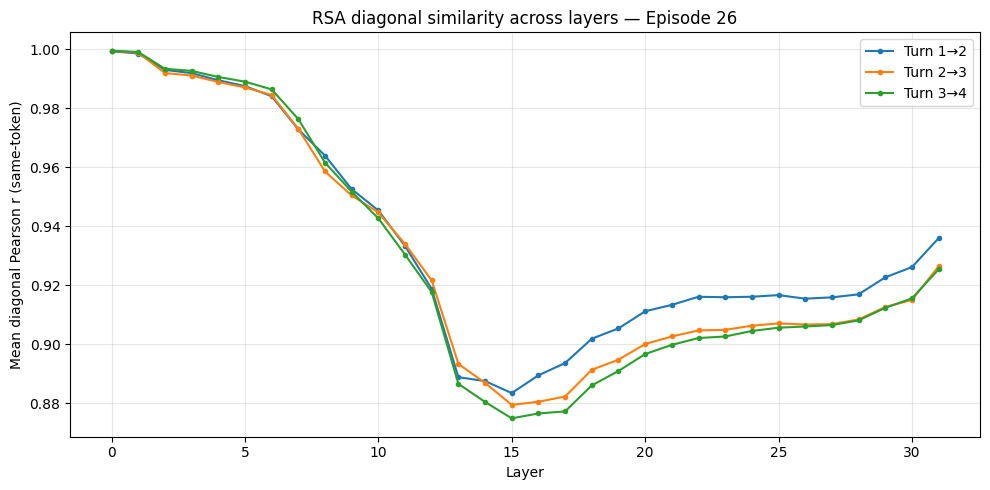

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

for si in shared_info:
    if si is None or si["n_shared"] == 0:
        continue
    
    t_a, t_b = si["turn_a"], si["turn_b"]
    ag_a, ag_b = si["agent_a"], si["agent_b"]
    idx_a, idx_b = si["idx_a"], si["idx_b"]
    
    states_a = load_states(t_a, ag_a)
    states_b = load_states(t_b, ag_b)
    
    diag_means = []
    for layer in range(32):
        corr = compute_rsa_matrix(states_a, states_b, idx_a, idx_b, layer)
        diag_means.append(np.mean(np.diag(corr)))
    
    ax.plot(range(32), diag_means, marker=".", label=f"Turn {t_a}→{t_b}")

ax.set_xlabel("Layer")
ax.set_ylabel("Mean diagonal Pearson r (same-token)")
ax.set_title(f"RSA diagonal similarity across layers — Episode {EPISODE}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. RSA across layers — turn-specific (new tokens only)

Same as above, but each turn pair only includes tokens from the **newly added dialog turn**, excluding tokens already present in earlier pairs. For example:
- Turn 1→2 shares "Turn 0: ..." — all those tokens are included (same as before, since this is the first pair).
- Turn 2→3 shares "Turn 0: ..." and "Turn 1: ..." — we only use the tokens from "Turn 1: ...", since "Turn 0: ..." was already counted in the 1→2 pair.
- Turn 3→4 shares turns 0, 1, 2 — we only use tokens from "Turn 2: ...".

Turn 1→2: 53 new tokens (of 53 total shared)
Turn 2→3: 77 new tokens (of 130 total shared)
Turn 3→4: 63 new tokens (of 193 total shared)


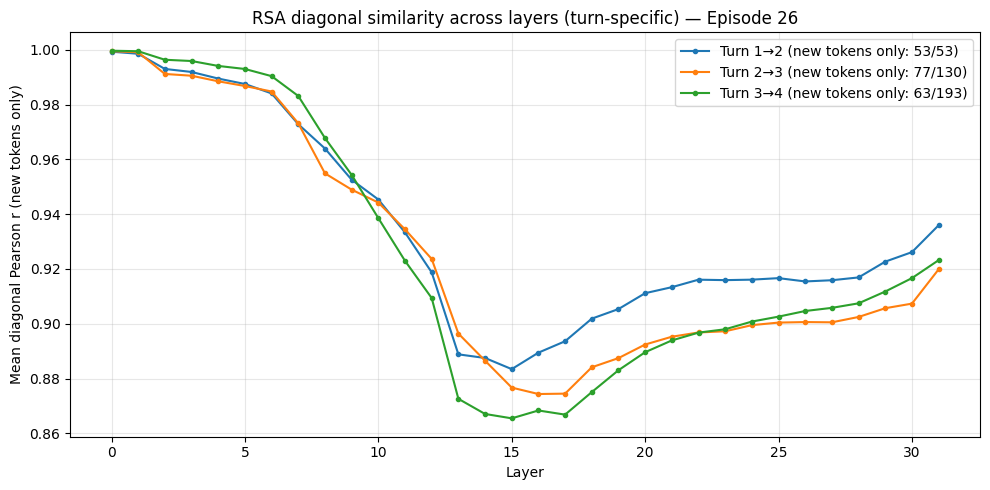

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

prev_n_shared = 0  # how many shared tokens the previous pair had

for si in shared_info:
    if si is None or si["n_shared"] == 0:
        continue
    
    t_a, t_b = si["turn_a"], si["turn_b"]
    ag_a, ag_b = si["agent_a"], si["agent_b"]
    idx_a, idx_b = si["idx_a"], si["idx_b"]
    n_shared = si["n_shared"]
    
    # Only use the NEW tokens: skip the first `prev_n_shared` positions
    # which correspond to dialog turns already covered by earlier pairs.
    new_idx_a = idx_a[prev_n_shared:]
    new_idx_b = idx_b[prev_n_shared:]
    n_new = len(new_idx_a)
    
    if n_new == 0:
        print(f"Turn {t_a}→{t_b}: no new tokens beyond previous pair, skipping.")
        prev_n_shared = n_shared
        continue
    
    states_a = load_states(t_a, ag_a)
    states_b = load_states(t_b, ag_b)
    
    diag_means = []
    for layer in range(32):
        corr = compute_rsa_matrix(states_a, states_b, new_idx_a, new_idx_b, layer)
        diag_means.append(np.mean(np.diag(corr)))
    
    label = f"Turn {t_a}→{t_b} (new tokens only: {n_new}/{n_shared})"
    ax.plot(range(32), diag_means, marker=".", label=label)
    print(f"Turn {t_a}→{t_b}: {n_new} new tokens (of {n_shared} total shared)")
    
    prev_n_shared = n_shared

ax.set_xlabel("Layer")
ax.set_ylabel("Mean diagonal Pearson r (new tokens only)")
ax.set_title(f"RSA diagonal similarity across layers (turn-specific) — Episode {EPISODE}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Sentence-level RSA for new dialog (mean-pool vs last-token)

For each turn pair, we extract the **new dialog tokens** (the latest turn's text
that both models have seen). We then construct a single sentence embedding from
each agent's token representations using two methods:
1. **Mean pooling**: average of all token representations in the span.
2. **Last token**: the representation of the final token in the span (causal summary).

We compute Pearson r between the two agents' sentence embeddings at each layer,
and summarize the results in a table.


 Turn pair       Agents  #Tok | MeanPool avg     L0    L16    L31 |  LastTok avg     L0    L16    L31 | Text
------------------------------------------------------------------------------------------------------------------------------------------
      T1→2   ag2 vs ag1    53 |       0.9602  0.999  0.918  0.971 |       0.9250  1.000  0.909  0.809 | Turn0:EliDawsonsaid:(Examiningthetablecarefully)Thisisabeaut...
      T2→3   ag1 vs ag2    77 |       0.9548  0.999  0.892  0.965 |       0.9231  1.000  0.865  0.887 | 
Turn1:WilliamBrownsaid:Eli,I'mgladyouappreciatethetable'sbe...
      T3→4   ag2 vs ag1    63 |       0.9508  1.000  0.891  0.974 |       0.9462  1.000  0.885  0.933 | 
Turn2:EliDawsonsaid:GivenmybudgetandtheadditionalgoalsIhave...

Saved: /juice6/u/jshe/nlp/LM_neural_synchrony/playground/plots/TEST_episode_26/rsa_sentence_level_new_dialog.pdf


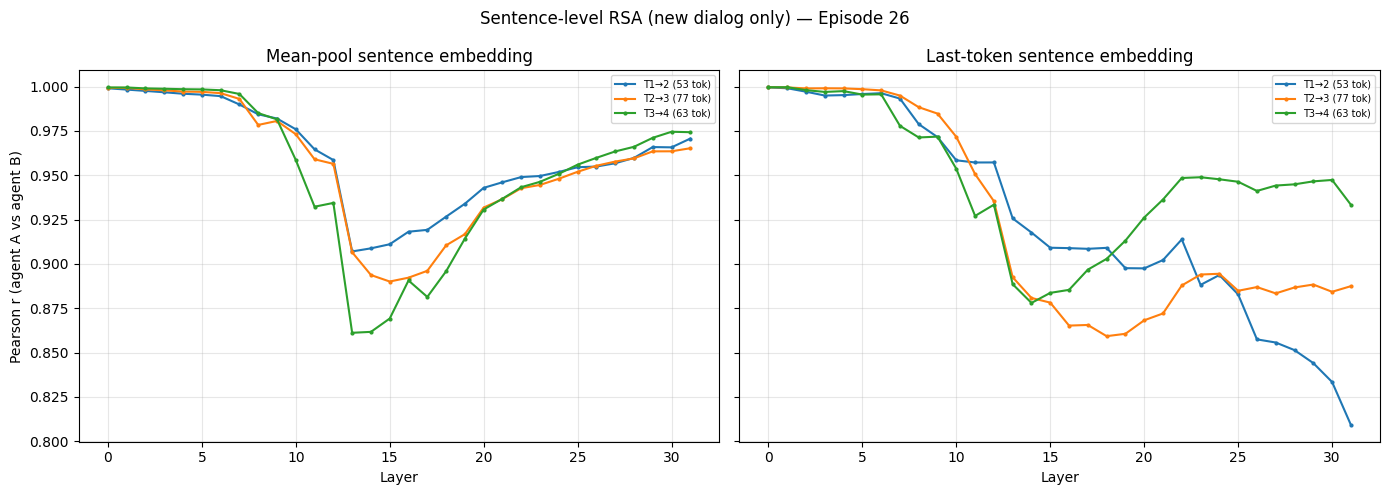

In [17]:
from scipy.stats import pearsonr

rows = []
prev_n_shared = 0

for si in shared_info:
    if si is None or si["n_shared"] == 0:
        prev_n_shared = 0
        continue

    t_a, t_b = si["turn_a"], si["turn_b"]
    ag_a, ag_b = si["agent_a"], si["agent_b"]
    idx_a, idx_b = si["idx_a"], si["idx_b"]
    n_shared = si["n_shared"]

    new_idx_a = idx_a[prev_n_shared:]
    new_idx_b = idx_b[prev_n_shared:]
    n_new = len(new_idx_a)

    if n_new == 0:
        prev_n_shared = n_shared
        continue

    states_a = load_states(t_a, ag_a)
    states_b = load_states(t_b, ag_b)

    new_dialog_text = si["token_strs"][prev_n_shared:]
    text_preview = "".join(new_dialog_text)[:60]

    mean_pool_r = []
    last_tok_r = []

    for layer in range(32):
        vecs_a = states_a[layer, new_idx_a, :].astype(np.float64)
        vecs_b = states_b[layer, new_idx_b, :].astype(np.float64)

        # Method 1: mean pooling
        emb_a_mean = vecs_a.mean(axis=0)
        emb_b_mean = vecs_b.mean(axis=0)
        r_mean, _ = pearsonr(emb_a_mean, emb_b_mean)
        mean_pool_r.append(r_mean)

        # Method 2: last token
        emb_a_last = vecs_a[-1]
        emb_b_last = vecs_b[-1]
        r_last, _ = pearsonr(emb_a_last, emb_b_last)
        last_tok_r.append(r_last)

    rows.append({
        "turn_pair": f"T{t_a}\u2192{t_b}",
        "agents": f"ag{ag_a} vs ag{ag_b}",
        "n_new_tokens": n_new,
        "text_preview": text_preview,
        "mean_pool_r_avg": np.mean(mean_pool_r),
        "mean_pool_r_L0": mean_pool_r[0],
        "mean_pool_r_L16": mean_pool_r[16],
        "mean_pool_r_L31": mean_pool_r[31],
        "last_tok_r_avg": np.mean(last_tok_r),
        "last_tok_r_L0": last_tok_r[0],
        "last_tok_r_L16": last_tok_r[16],
        "last_tok_r_L31": last_tok_r[31],
        "mean_pool_all": mean_pool_r,
        "last_tok_all": last_tok_r,
    })

    prev_n_shared = n_shared

# Print summary table
header = f"{'Turn pair':>10s} {'Agents':>12s} {'#Tok':>5s} | "\
         f"{'MeanPool avg':>12s} {'L0':>6s} {'L16':>6s} {'L31':>6s} | "\
         f"{'LastTok avg':>12s} {'L0':>6s} {'L16':>6s} {'L31':>6s} | Text"
print(header)
print("-" * len(header) + "-" * 30)

for r in rows:
    print(
        f"{r['turn_pair']:>10s} {r['agents']:>12s} {r['n_new_tokens']:>5d} | "
        f"{r['mean_pool_r_avg']:>12.4f} {r['mean_pool_r_L0']:>6.3f} "
        f"{r['mean_pool_r_L16']:>6.3f} {r['mean_pool_r_L31']:>6.3f} | "
        f"{r['last_tok_r_avg']:>12.4f} {r['last_tok_r_L0']:>6.3f} "
        f"{r['last_tok_r_L16']:>6.3f} {r['last_tok_r_L31']:>6.3f} | "
        f"{r['text_preview']}..."
    )

# Also plot both methods across layers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for r in rows:
    ax1.plot(range(32), r["mean_pool_all"], marker=".", markersize=4,
            label=f"{r['turn_pair']} ({r['n_new_tokens']} tok)")
    ax2.plot(range(32), r["last_tok_all"], marker=".", markersize=4,
            label=f"{r['turn_pair']} ({r['n_new_tokens']} tok)")

ax1.set_title("Mean-pool sentence embedding")
ax1.set_xlabel("Layer")
ax1.set_ylabel("Pearson r (agent A vs agent B)")
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

ax2.set_title("Last-token sentence embedding")
ax2.set_xlabel("Layer")
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

fig.suptitle(f"Sentence-level RSA (new dialog only) \u2014 Episode {EPISODE}", fontsize=12)
plt.tight_layout()

pdf_path = os.path.join(PLOT_DIR, "rsa_sentence_level_new_dialog.pdf")
fig.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
print(f"\nSaved: {pdf_path}")
plt.show()


## 8. SBERT token-level RSA for new dialog (all layers)

We encode each agent's new dialog text through `all-MiniLM-L6-v2` and extract
per-token hidden states at all 7 layers (embedding + 6 transformer layers).
For each layer we compute:
1. **Mean-pool** sentence embedding Pearson r between agents.
2. **Last-token** embedding Pearson r between agents.
3. **Mean diagonal** token-level Pearson r (same-position tokens).


SBERT model loaded: 7 layers, hidden_size=384
T1→2: sbert=47 aligned tok | Turn 0: Eli Dawson said:(Examining the table carefully) This...
T2→3: sbert=70 aligned tok | 
Turn 1: William Brown said:Eli, I'm glad you appreciate the...
T3→4: sbert=58 aligned tok | 
Turn 2: Eli Dawson said:Given my budget and the additional ...

  Turn |       Method |  Layer avg |     L0 |     L3 |     L6
--------------------------------------------------------------------------------
  T1→2 |    mean_pool |     0.9910 |  1.000 |  0.995 |  0.958
  T1→2 |     last_tok |     0.9868 |  1.000 |  0.987 |  0.960
  T1→2 |         diag |     0.9809 |  1.000 |  0.979 |  0.959
--------------------------------------------------------------------------------
  T2→3 |    mean_pool |     0.9918 |  1.000 |  0.996 |  0.961
  T2→3 |     last_tok |     0.9794 |  1.000 |  0.983 |  0.945
  T2→3 |         diag |     0.9842 |  1.000 |  0.982 |  0.967
------------------------------------------------------------------------------

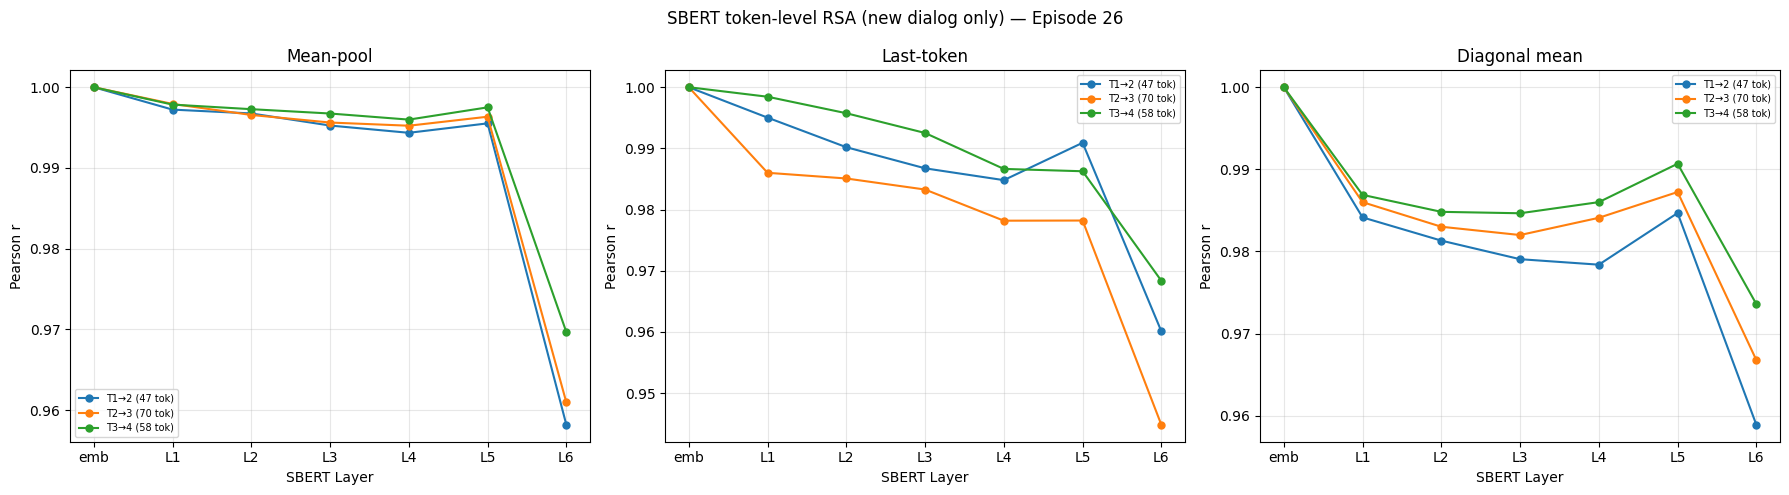

In [22]:
from sentence_transformers import SentenceTransformer
import torch

sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
sbert_tokenizer = sbert_model[0].tokenizer
sbert_auto_model = sbert_model[0].auto_model
sbert_auto_model.eval()
N_SBERT_LAYERS = sbert_auto_model.config.num_hidden_layers + 1  # 7 (emb + 6)
print(f"SBERT model loaded: {N_SBERT_LAYERS} layers, hidden_size={sbert_auto_model.config.hidden_size}")


def sbert_encode_all_layers(text):
    """Encode text and return per-token hidden states at all layers.
    Returns: np.array of shape (n_layers, n_tokens, hidden_dim) — excludes [CLS]/[SEP]."""
    enc = sbert_tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        out = sbert_auto_model(**enc, output_hidden_states=True)
    all_hs = torch.stack(out.hidden_states, dim=0).squeeze(1)  # (n_layers, seq_len, hidden_dim)
    all_hs = all_hs[:, 1:-1, :]  # remove [CLS] and [SEP]
    return all_hs.numpy()


def get_span_indices(offsets, text_start, text_end):
    indices = []
    for idx, (cs, ce) in enumerate(offsets):
        if cs == 0 and ce == 0:
            continue
        if ce > text_start and cs < text_end:
            indices.append(idx)
    return indices


sbert_rows = []
prev_n_shared = 0

for si in shared_info:
    if si is None or si["n_shared"] == 0:
        prev_n_shared = 0
        continue

    t_a, t_b = si["turn_a"], si["turn_b"]
    ag_a, ag_b = si["agent_a"], si["agent_b"]
    n_shared = si["n_shared"]

    new_token_strs = si["token_strs"][prev_n_shared:]
    n_new = len(new_token_strs)

    if n_new == 0:
        prev_n_shared = n_shared
        continue

    # Extract the actual dialog substring from the wrapped prompt using Mistral token offsets
    tt_a = turn_tokens[t_a]
    new_idx_a = si["idx_a"][prev_n_shared:]
    char_start = tt_a["offsets"][new_idx_a[0]][0]
    char_end = tt_a["offsets"][new_idx_a[-1]][1]
    new_dialog_text = tt_a["wrapped_prompt"][char_start:char_end]
    text_preview = new_dialog_text[:60]

    # Encode each agent's prompt with the dialog placed first to avoid truncation.
    # Format: "[new dialog] [SEP] [rest of prompt]" — ensures dialog tokens survive 512 limit.
    prompt_a = tt_a["wrapped_prompt"]
    prompt_b = turn_tokens[t_b]["wrapped_prompt"]

    def build_dialog_first_input(full_prompt, dialog_text):
        """Put dialog at the start so it survives SBERT's 512-token truncation."""
        pos = full_prompt.find(dialog_text)
        if pos < 0:
            return dialog_text
        before = full_prompt[:pos].strip()
        after = full_prompt[pos + len(dialog_text):].strip()
        context = (before + " " + after).strip()
        return dialog_text + " [SEP] " + context

    input_a = build_dialog_first_input(prompt_a, new_dialog_text)
    input_b = build_dialog_first_input(prompt_b, new_dialog_text)

    states_sbert_a = sbert_encode_all_layers(input_a)  # (7, n_tok_a, 384)
    states_sbert_b = sbert_encode_all_layers(input_b)  # (7, n_tok_b, 384)

    # The dialog tokens are now at the start — find their indices
    enc_a = sbert_tokenizer(input_a, truncation=True, max_length=512, return_offsets_mapping=True)
    enc_b = sbert_tokenizer(input_b, truncation=True, max_length=512, return_offsets_mapping=True)
    offsets_a = enc_a["offset_mapping"][1:-1]
    offsets_b = enc_b["offset_mapping"][1:-1]

    # Dialog is at position 0 in the rearranged input
    dialog_len = len(new_dialog_text)
    sbert_idx_a = get_span_indices(offsets_a, 0, dialog_len)
    sbert_idx_b = get_span_indices(offsets_b, 0, dialog_len)
    n_sbert_aligned = min(len(sbert_idx_a), len(sbert_idx_b))
    sbert_idx_a = sbert_idx_a[:n_sbert_aligned]
    sbert_idx_b = sbert_idx_b[:n_sbert_aligned]

    sbert_mean_pool_r = []
    sbert_last_tok_r = []
    sbert_diag_r = []

    if n_sbert_aligned > 0:
        for layer in range(N_SBERT_LAYERS):
            va = states_sbert_a[layer][sbert_idx_a].astype(np.float64)
            vb = states_sbert_b[layer][sbert_idx_b].astype(np.float64)
            r_mean, _ = pearsonr(va.mean(axis=0), vb.mean(axis=0))
            r_last, _ = pearsonr(va[-1], vb[-1])
            sbert_mean_pool_r.append(r_mean)
            sbert_last_tok_r.append(r_last)
            diags = [pearsonr(va[k], vb[k])[0] for k in range(n_sbert_aligned)]
            sbert_diag_r.append(np.mean(diags))
    else:
        sbert_mean_pool_r = [np.nan] * N_SBERT_LAYERS
        sbert_last_tok_r = [np.nan] * N_SBERT_LAYERS
        sbert_diag_r = [np.nan] * N_SBERT_LAYERS

    sbert_rows.append({
        "turn_pair": f"T{t_a}\u2192{t_b}",
        "n_sbert_tok": n_sbert_aligned,
        "text_preview": text_preview,
        "sbert_mean_pool": sbert_mean_pool_r,
        "sbert_last_tok": sbert_last_tok_r,
        "sbert_diag": sbert_diag_r,
    })

    print(f"T{t_a}\u2192{t_b}: sbert={n_sbert_aligned} aligned tok | {text_preview}...")
    prev_n_shared = n_shared

# --- Table summary ---
print("\n" + "=" * 80)
print(f"{'Turn':>6s} | {'Method':>12s} | {'Layer avg':>10s} | {'L0':>6s} | {'L3':>6s} | {'L6':>6s}")
print("-" * 80)
for r in sbert_rows:
    tp = r["turn_pair"]
    for method in ["mean_pool", "last_tok", "diag"]:
        vals = r[f"sbert_{method}"]
        print(f"{tp:>6s} | {method:>12s} | "
              f"{np.nanmean(vals):>10.4f} | {vals[0]:>6.3f} | {vals[3]:>6.3f} | {vals[-1]:>6.3f}")
    print("-" * 80)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
method_titles = ["Mean-pool", "Last-token", "Diagonal mean"]
method_keys = ["mean_pool", "last_tok", "diag"]

for ax, mtitle, mkey in zip(axes, method_titles, method_keys):
    for r in sbert_rows:
        ax.plot(range(N_SBERT_LAYERS), r[f"sbert_{mkey}"], marker="o", markersize=5,
                label=f"{r['turn_pair']} ({r['n_sbert_tok']} tok)")
    ax.set_title(mtitle)
    ax.set_xlabel("SBERT Layer")
    ax.set_xticks(range(N_SBERT_LAYERS))
    ax.set_xticklabels(["emb"] + [f"L{i+1}" for i in range(N_SBERT_LAYERS - 1)])
    ax.set_ylabel("Pearson r")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"SBERT token-level RSA (new dialog only) \u2014 Episode {EPISODE}", fontsize=12)
plt.tight_layout()
pdf_path = os.path.join(PLOT_DIR, "rsa_sbert_new_dialog.pdf")
fig.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
print(f"\nSaved: {pdf_path}")
plt.show()
